In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
from pathlib import Path
from itertools import groupby
from operator import itemgetter
from CustomFunctions import DetailedBalance, utils

In [8]:
####### load common directories FOR APPLIED CONFOCAL PCA
time_interval = 5 #sec/frame
whichpcs = [1,2]
basedir = Path('E:/Aaron/Combined_37C_Confocal_PCA_planar_LLS_Apply')
datadir = basedir.joinpath('Data_and_Figs')
savedir = basedir.joinpath('Detailed_Balance/')
if not savedir.exists():
    savedir.mkdir()
FullFrame = pd.read_csv(datadir.joinpath('All_Data_with_CGPS_bins.csv'), index_col=0)
centers = pd.read_csv(datadir.joinpath('PC_bin_centers.csv'), index_col=0)
nbins = len(centers.iloc[:,0])
ttot = time_interval * 180
ntranslist = [1,2,3]
bsiter = 3000



## restrict the treatments and PCs specifically for bootstrapping
bstreats = []#['Random','Galvanotaxis', 'DMSO', 'CK666','Para-Nitro-Blebbistatin']
bspcs = [[1,2]]
alldatabs = False

In [9]:
#### all the cgps origins determinned by visual inspection

# #### WIDTH alignment origins
# allorigins = [[[8,8],[8,8],[9,8],[8,8],[9,7],[9,8],[9,8]],
#                 [[8,8],[8,8],[8,8],[8,8],[8,8],[8,8]],
#                     [[8,8],[8,8],[8,8],[8,8],[8,8]],
#                         [[8,8],[8,8],[8,8],[8,8]],
#                             [[8,8],[8,8],[8,8]],
#                                 [[6,8],[8,8]],
#                                     [[8,8]]]

#### PLANAR alignment origins
allorigins = [[[9,10],[8,6],[8,9],[8,8],[8,8],[8,8],[9,7]],
                [[8,6],[8,9],[8,8],[8,7],[8,7],[8,8]],
                    [[8,8],[7,8],[8,8],[8,8],[9,8]],
                        [[9,8],[7,8],[8,8],[8,8]],
                            [[8,8],[8,8],[8,8]],
                                [[8,7],[8,8]],
                                    [[8,8]]]

In [3]:
############# create all CGPSs #############

npcs = centers.shape[1]
for a in range(1,npcs+1):
    for b in range(1,npcs+1):
        if a == b:
            continue
        elif savedir.joinpath(f'PC{b}-PC{a}_interpolated_transitions_separated.csv').exists():
            print('Already made this CGPS')
            continue
        else:
            #set the PCs
            whichpcs = [a,b]
            if __name__ ==  '__main__':
                
                ########### get raw transitions and pairs ###########
                rawtrans = DetailedBalance.get_raw_cgps_trajectories(
                        FullFrame, #pandas dataframe with all of the cgps binned data
                        whichpcs, #which two PCs to use in the cgps [x,y]
                        time_interval, #real time between datapoints
                        savedir, #where to save the aggregated trajectories
                        )
                
                ########### interpolate all transitions so that only individual transitions are made ###########
                transdf_sep = DetailedBalance.get_interpolated_cgps_trajectories(
                        rawtrans, #pandas dataframe with all of the cgps binned data
                        whichpcs, #which two PCs to use in the cgps [x,y]
                        savedir, #where to save the aggregated trajectories
                        )

                ############## get the counts of cells leaving 
                trans_rate_df_sep = DetailedBalance.aggregate_transition_counts(
                        transdf_sep, #transdf_sep from get_interpolated_cgps_trajectories
                        whichpcs, #which two PCs to use in the cgps [x,y]
                        savedir, #where to save the aggregated counts
                        nbins, #how many bins in the x and y cgps axes
                        )
                
                
            

Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 494.9719140383019 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 499.85870812471836 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 500.7325707628359 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 496.5302710134536 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 497.1552897172826 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total time observed in this CGPS was 500.005621387774 minutes
Finished finding transition rates
Aggregated transitions
Finished interpolating trajectories
Total

In [10]:
########### bootstrap transitions and calculate all the aers and cfs around all the pairwise cgps ###############

npcs = centers.shape[1]
for ntrans_num in ntranslist:
    for a in range(1,npcs+1):
        for b in range(1,npcs+1):
            #set the PCs
            whichpcs = [a,b]
            #pass if we want to restrict PCs
            if len(bspcs)>0 and whichpcs not in bspcs:
                continue
            ## use a separate savedir to bootstrap using all data
            if alldatabs:
                bssavedir = savedir.joinpath('alldatabs')
                if not bssavedir.exists():
                    bssavedir.mkdir()
            else:
                bssavedir = savedir

            if a == b:
                continue
            elif bssavedir.joinpath(f'PC{b}-PC{a}_bootstrapped_{ntrans_num}_transitions.csv').exists():
                print('Already made this plot')
                continue
            else:
                if __name__ ==  '__main__':
                    #### open the transitions
                    rawtrans = pd.read_csv(savedir.joinpath(
                        f'PC{whichpcs[0]}-PC{whichpcs[1]}_transitions_separated.csv'), index_col=0)

                    #merge all treatments if bootstrapping with all data
                    if alldatabs:
                        rawtrans.loc[:,'Treatment'] = 'alldata'

                    #restrict to bootstrapped treatments if desired
                    if len(bstreats)>0:
                        rawtrans = rawtrans[rawtrans.Treatment.isin(bstreats)]


                    ############## BOOTSTRAP MANY TRAJECTORIES ##########
                    bstrans, bsint, bsframe_sep_full = DetailedBalance.get_bootstrapped_cgps_trajectories(
                            rawtrans, #raw transition pairs from get_raw_cgps_trajectories
                            whichpcs, #which two PCs to use in the cgps [x,y]
                            time_interval, #real time between datapoints
                            bssavedir, #where to save the aggregated counts
                            nbins, #how many bins in the x and y cgps axes
                            ttot, #set the total bootstrap time
                            ntrans_num, #how many transitions to sample at each step
                            bsiter, #number of times to bootstrap
                            )


                    ############# open average bootstrapped currents ###################
                    bsfield_sep = DetailedBalance.get_avg_current_error(
                            bsframe_sep_full, #transition rates in the cgps from get_bootstrapped_cgps_trajectories
                            whichpcs, #which two PCs to use in the cgps [x,y]
                            bssavedir, #where to save the aggregated counts
                            nbins, #how many bins in the x and y cgps axes
                            ntrans_num, #how many transitions to sample at each step
                            )



                    ############# measure aer and cycling frequencies ###########
                    #add specific scaling
                    xyscaling = [centers[f'PC{whichpcs[0]}'].diff().mean(),centers[f'PC{whichpcs[1]}'].diff().mean()]
                    #set the origin to the actual center
                    center = allorigins[int(a-1)][int(b-(2+a-1))]

                    DetailedBalance.get_aer_cf(
                        bstrans,
                        nbins, #how many bins in the x and y cgps axes
                        xyscaling, #scaling of the bins in real units of whatever the CGPS axis parameters are
                        center, #origin in [x bin,y bin]
                        bssavedir, #where to save calculated aers and cfs
                        whichpcs, #which two PCs to use in the cgps [x,y]
                        ntrans_num, #how many transitions to sample at each step
                        )



                    ############### measure aer and cycling frequency for the raw transitions
                    #get the area scaling in x and y based on the size of the bins in the cgps
                    results = []
                    for i, cell in rawtrans.groupby('CellID'):
                        #sort data and get continuous transitions in order
                        cell, runs = utils.get_consecutive_transitions(cell)
                        for r in runs:
                            c = cell.iloc[r].reset_index(drop=True)
                            results.append(DetailedBalance.get_area_enclosing_rate((
                                c,
                                nbins,
                                xyscaling,
                                center,
                                )))

                    #make a dataframe and save it
                    allaers = pd.concat(results, ignore_index = True)
                    allaers.to_csv(bssavedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_raw_transition_aer_cf.csv'))



Boostrapping trajectories with 1 transition samples for Random


100%|██████████| 3000/3000 [01:04<00:00, 46.57it/s]


Interpolating trajectories for Random


100%|██████████| 3000/3000 [00:05<00:00, 555.12it/s] 


Calculating bootstrapped CGPS transition rates for Random


...

100%|██████████| 3000/3000 [00:05<00:00, 550.06it/s] 


Calculating bootstrapped CGPS transition rates for Random


100%|██████████| 3000/3000 [02:22<00:00, 21.08it/s]


Finished bootstrapping


100%|██████████| 3000/3000 [00:06<00:00, 466.11it/s]


In [17]:
############ create gaps in the bootstrapped data similar to the real data ############
ntrans = 1
for whichpcs in bspcs:
    justaers = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_raw_transition_aer_cf.csv'), index_col = 0)
    FullFrame['real_time'] = FullFrame.time.copy()
    realcelldf = FullFrame.merge(justaers[['CellID','aer','real_time','cumulative_time','time_elapsed']],
                                 on = ['CellID','real_time'], how = 'left')

    ########## measure gap frequency and duration
    allrunlengths, allrunlengthmeans, allgaplengths, allgaplengthmeans, allgapfrequencies = DetailedBalance.get_run_stats(
            realcelldf, #dataframe
            'CellID', #what is the identifier to group by as a str
            time_interval, #frame rate of the data
            )
    print(f'Average track run length mean for real data is {np.mean(allrunlengthmeans)} and mean gap frequency is {np.mean(allgapfrequencies)})')

    #### get bs data with gaps
    bsaers = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_{ntrans}_transition_Area_Enclosing_Rates.csv'), index_col=0)
    bstrans = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_bootstrapped_{ntrans}_transitions.csv'), index_col = 0)

    bs_with_gaps = DetailedBalance.bootstrap_runs(
        bsaers, #dataframe with bootstrap iterations (doesn't actually need aer)
        allrunlengths, #the sample of movies lengths in seconds
        allgaplengths, #the sample of non-movie gap lengths in seconds
        )

    ### measure the gap probability in the newly gapped bootstrap data
    #change real_time to just time
    bs_gap_measure = bs_with_gaps.merge(bsaers[['iter','real_time','cumulative_time','time_elapsed']], on = ['iter','real_time'], how = 'left')
    #add dummy column
    bs_gap_measure['aer'] = 0
    bsallrunlengths, bsallrunlengthmeans, bsallgaplengths, bsallgaplengthmeans, bsallgapfrequencies = DetailedBalance.get_run_stats(
            bs_gap_measure, #dataframe
            'iter', #what is the identifier to group by as a str
            time_interval, #frame rate of the data
            )

    print(f'Average track run length mean for bootstrapped data is {np.mean(bsallrunlengthmeans)} and mean gap frequency is {np.mean(bsallgapfrequencies)})')

    ### save the gapped bootstrap data
    bs_with_gaps.to_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_{ntrans}_transition_Area_Enclosing_Rates_gaps.csv'))


Average track run length mean for real data is 27.107146663057495 and mean gap frequency is 0.006773797742590091)


C:\ProgramData\anaconda3\envs\abhishape\lib\site-packages\numpy\core\fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
C:\ProgramData\anaconda3\envs\abhishape\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Average track run length mean for bootstrapped data is 29.55782246519762 and mean gap frequency is 0.005872731763529873)


C:\ProgramData\anaconda3\envs\abhishape\lib\site-packages\numpy\core\fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
C:\ProgramData\anaconda3\envs\abhishape\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\envs\abhishape\lib\site-packages\ipykernel_launcher.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


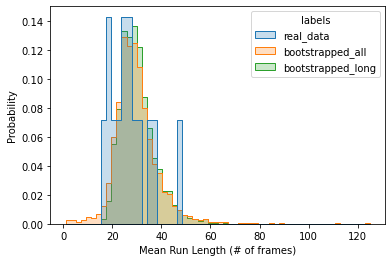

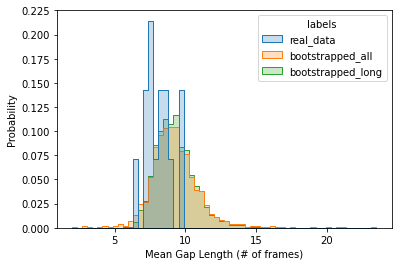

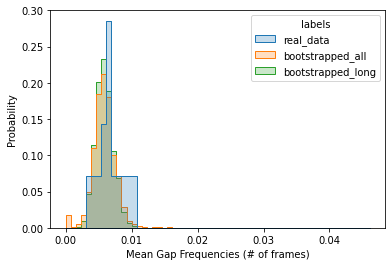

In [19]:
############ PLOT THE DISTRIBUTIONS OF REAL AND BOOTSTRAPPED GAPS AND RUNS ############
import matplotlib.pyplot as plt
import seaborn as sns



ntrans = 1
justaers = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_raw_transition_aer_cf.csv'), index_col = 0)
FullFrame['real_time'] = FullFrame.time.copy()
realcelldf = FullFrame.merge(justaers[['CellID','aer','real_time','cumulative_time','time_elapsed']],
                             on = ['CellID','real_time'], how = 'left')

########## measure gap frequency and duration
allrunlengths, allrunlengthmeans, allgaplengths, allgaplengthmeans, allgapfrequencies = DetailedBalance.get_run_stats(
        realcelldf, #dataframe
        'CellID', #what is the identifier to group by as a str
        time_interval, #frame rate of the data
        )

#### get bs data with gaps
bsaers = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_{ntrans}_transition_Area_Enclosing_Rates.csv'), index_col=0)
bs_with_gaps = pd.read_csv(savedir.joinpath(f'PC{whichpcs[0]}-PC{whichpcs[1]}_{ntrans}_transition_Area_Enclosing_Rates_gaps.csv'), index_col=0)

### measure the gap probability in the newly gapped bootstrap data
#change real_time to just time
bs_gap_measure = bs_with_gaps.merge(bsaers[['iter','real_time','cumulative_time','time_elapsed']], on = ['iter','real_time'], how = 'left')
#add dummy column
bs_gap_measure['aer'] = 0
bsallrunlengths, bsallrunlengthmeans, bsallgaplengths, bsallgaplengthmeans, bsallgapfrequencies = DetailedBalance.get_run_stats(
        bs_gap_measure, #dataframe
        'iter', #what is the identifier to group by as a str
        time_interval, #frame rate of the data
        )

############ limit bootstrapped data to long iterations only
longiters = bs_with_gaps.iter.value_counts()>realcelldf[~realcelldf.aer.isna()].CellID.value_counts().min()
longbs = bs_gap_measure[bs_gap_measure.iter.isin(longiters[longiters==True].index.to_list())]
#add dummy column
longbs['aer'] = 0
bsallrunlengthslong, bsallrunlengthmeanslong, bsallgaplengthslong, bsallgaplengthmeanslong, bsallgapfrequencieslong = DetailedBalance.get_run_stats(
        longbs, #dataframe
        'iter', #what is the identifier to group by as a str
        time_interval, #frame rate of the data
        )


################ PLOT THE REAL AND BOOTSTRAPPED DISTRIBUTIONS FOR 
################ VARIOUS RUN AND GAP STATS 
################ 
labels = ['real_data','bootstrapped_all','bootstrapped_long']


############## run lengths
data = [allrunlengthmeans,bsallrunlengthmeans,bsallrunlengthmeanslong]
all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
tempdf = pd.DataFrame({
            'labels': np.concatenate(all_labels),
            'data': np.concatenate(data)
            })

fig, ax = plt.subplots()
sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
             element = 'step', common_norm = False, ax = ax)
ax.set_xlabel('Mean Run Length (# of frames)')
plt.savefig(savedir.joinpath('bootstrapped_data_gap_qc_mean_run_lengths.png'))



############## gap lengths
data = [allgaplengthmeans,bsallgaplengthmeans,bsallgaplengthmeanslong]
all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
tempdf = pd.DataFrame({
            'labels': np.concatenate(all_labels),
            'data': np.concatenate(data)
            })

fig, ax = plt.subplots()
sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
             element = 'step', common_norm = False, ax = ax)
ax.set_xlabel('Mean Gap Length (# of frames)')
plt.savefig(savedir.joinpath('bootstrapped_data_gap_qc_mean_gap_lengths.png'))


############## gap frequencies
data = [allgapfrequencies,bsallgapfrequencies,bsallgapfrequencieslong]
all_labels = [[labels[i]]*len(x) for i, x in enumerate(data)]
tempdf = pd.DataFrame({
            'labels': np.concatenate(all_labels),
            'data': np.concatenate(data)
            })

fig, ax = plt.subplots()
sns.histplot(data = tempdf, x = 'data', hue = 'labels', bins = 60, stat = 'probability',
             element = 'step', common_norm = False, ax = ax)
ax.set_xlabel('Mean Gap Frequencies (# of frames)')
plt.savefig(savedir.joinpath('bootstrapped_data_gap_qc_mean_gap_frequencies.png'))